## SMT 공정 관련 v1 코드

#### 라이브러리 로드

In [4]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
import cv2

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image as keras_image
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

#### 경로 설정

In [15]:
DATA_ROOT = "./smt_data"

SENSOR_DATA_DIR = {
    'defect': os.path.join(DATA_ROOT, "Sample/01.원천데이터/센서데이터/사전공정/불량/1.미납"),
    'normal': os.path.join(DATA_ROOT, "Sample/01.원천데이터/센서데이터/사전공정/정상/1.미납")
}
 
IMAGE_DATA_DIR = {
    'defect': os.path.join(DATA_ROOT, "Sample/01.원천데이터/이미지데이터/사전공정/불량/1.미납"),
    'normal': os.path.join(DATA_ROOT, "Sample/01.원천데이터/이미지데이터/사전공정/정상/1.미납")
}

OUTPUT_DIR = "/mnt/user-data/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

#### 파일 쌍 찾기

In [17]:
def get_file_pairs(sensor_dir, image_dir):
    sensor_files = sorted([f for f in os.listdir(sensor_dir) if f.endswith('.xlsx')])
    pairs = []
    for sensor_file in sensor_files:
        base_name = sensor_file.replace('.xlsx', '')
        image_file = base_name + '.JPG'
        image_path = os.path.join(image_dir, image_file)
        sensor_path = os.path.join(sensor_dir, sensor_file)
        
        if os.path.exists(image_path):
            pairs.append({
                'base_name': base_name,
                'sensor_path': sensor_path,
                'image_path': image_path
            })
    return pairs

defect_pairs = get_file_pairs(SENSOR_DATA_DIR['defect'], IMAGE_DATA_DIR['defect'])
normal_pairs = get_file_pairs(SENSOR_DATA_DIR['normal'], IMAGE_DATA_DIR['normal'])

In [19]:
base_model = MobileNetV2(weights='imagenet', include_top=False)

In [20]:
def load_sensor_data(excel_path):
    df = pd.read_excel(excel_path)
    return df
 
def load_image(image_path):
    img = Image.open(image_path)
    return np.array(img)
 
def extract_image_features(image_array, model):
    img_resized = cv2.resize(image_array, (224, 224))
    img_normalized = keras_image.smart_resize(img_resized, (224, 224))
    img_batch = np.expand_dims(img_normalized, axis=0)
    features = model.predict(img_batch, verbose=0)
    features_flat = features.reshape(-1)
    return features_flat

#### 불량 / 정상 데이터 처리

In [21]:
defect_data = []
 
for idx, pair in enumerate(defect_pairs):
    sensor_df = load_sensor_data(pair['sensor_path'])
    image_array = load_image(pair['image_path'])
    image_features = extract_image_features(image_array, base_model)
    
    sensor_stats = {
        'sample_id': pair['base_name'],
        'label': 1,
        'image_features': image_features
    }
    
    # 센서 통계
    for col in sensor_df.columns:
        if sensor_df[col].dtype in [np.float64, np.int64]:
            sensor_stats[f'{col}_mean'] = sensor_df[col].mean()
            sensor_stats[f'{col}_std'] = sensor_df[col].std()
            sensor_stats[f'{col}_max'] = sensor_df[col].max()
            sensor_stats[f'{col}_min'] = sensor_df[col].min()
    
    defect_data.append(sensor_stats)
    
    if (idx + 1) % 10 == 0:
        print(f"  불량 {idx + 1}/{len(defect_pairs)} 완료")

  불량 10/50 완료
  불량 20/50 완료
  불량 30/50 완료
  불량 40/50 완료
  불량 50/50 완료


In [22]:
normal_data = []
 
for idx, pair in enumerate(normal_pairs):
    sensor_df = load_sensor_data(pair['sensor_path'])
    image_array = load_image(pair['image_path'])
    image_features = extract_image_features(image_array, base_model)
    
    sensor_stats = {
        'sample_id': pair['base_name'],
        'label': 0,
        'image_features': image_features
    }
    
    for col in sensor_df.columns:
        if sensor_df[col].dtype in [np.float64, np.int64]:
            sensor_stats[f'{col}_mean'] = sensor_df[col].mean()
            sensor_stats[f'{col}_std'] = sensor_df[col].std()
            sensor_stats[f'{col}_max'] = sensor_df[col].max()
            sensor_stats[f'{col}_min'] = sensor_df[col].min()
    
    normal_data.append(sensor_stats)
    
    if (idx + 1) % 10 == 0:
        print(f"  정상 {idx + 1}/{len(normal_pairs)} 완료")

  정상 10/50 완료
  정상 20/50 완료
  정상 30/50 완료
  정상 40/50 완료
  정상 50/50 완료


#### 이미지 특성 행렬 생성

In [25]:
X_image_features = np.array([d['image_features'] for d in defect_data])
 
print("이미지 특성 행렬 생성 완료")
print(f"  형태: {X_image_features.shape}")
print(f"  샘플: {X_image_features.shape[0]}")
print(f"  특성: {X_image_features.shape[1]}")

이미지 특성 행렬 생성 완료
  형태: (50, 62720)
  샘플: 50
  특성: 62720


In [26]:
silhouette_scores = []
K_range = range(2, min(10, len(defect_data)))
 
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_image_features)
    score = silhouette_score(X_image_features, labels_temp)
    silhouette_scores.append(score)
    print(f"  K={k}: {score:.4f}")
 
optimal_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"\n✓ 최적 클러스터 수: {optimal_k}가지")

  K=2: 0.0777
  K=3: 0.0732
  K=4: 0.0602
  K=5: 0.0489
  K=6: 0.0490
  K=7: 0.0543
  K=8: 0.0458
  K=9: 0.0412

✓ 최적 클러스터 수: 2가지


In [27]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
defect_types = kmeans.fit_predict(X_image_features)
 
for idx, d in enumerate(defect_data):
    d['defect_type'] = int(defect_types[idx])
 
print("Clustering 완료")
 
for dtype in range(optimal_k):
    count = len([d for d in defect_data if d['defect_type'] == dtype])
    print(f"  불량타입 {dtype}: {count}개")

Clustering 완료
  불량타입 0: 25개
  불량타입 1: 25개


In [28]:
normal_stats = {}
 
for col in normal_data[0].keys():
    if col.endswith('_mean'):
        sensor_name = col.replace('_mean', '')
        values = [d[col] for d in normal_data if col in d]
        if values:
            normal_stats[sensor_name] = {
                'mean': np.mean(values),
                'std': np.std(values)
            }
 
print(f"✓ 정상 데이터 통계 완료: {len(normal_stats)}개 센서")

✓ 정상 데이터 통계 완료: 5개 센서


In [29]:
analysis_results = {}
 
for dtype in range(optimal_k):
    type_data = [d for d in defect_data if d['defect_type'] == dtype]
    
    print(f"\n🔴 불량타입 {dtype} ({len(type_data)}개)")
    
    type_analysis = {
        'count': len(type_data),
        'sample_ids': [d['sample_id'] for d in type_data],
        'sensor_analysis': {}
    }
    
    for col in normal_data[0].keys():
        if col.endswith('_mean'):
            sensor_name = col.replace('_mean', '')
            values = [d[col] for d in type_data if col in d]
            
            if values and sensor_name in normal_stats:
                type_mean = np.mean(values)
                type_std = np.std(values)
                normal_mean = normal_stats[sensor_name]['mean']
                diff = type_mean - normal_mean
                diff_pct = (diff / normal_mean * 100) if normal_mean != 0 else 0
                status = "↑ 높음" if diff > 0 else "↓ 낮음"
                
                type_analysis['sensor_analysis'][sensor_name] = {
                    'type_mean': round(type_mean, 3),
                    'normal_mean': round(normal_mean, 3),
                    'diff': round(diff, 3),
                    'diff_pct': round(diff_pct, 2),
                    'status': status
                }
                
                print(f"  {sensor_name}: {type_mean:.2f} vs {normal_mean:.2f} ({diff_pct:+.1f}%) {status}")
    
    analysis_results[dtype] = type_analysis
 
print("\n✓ 센서 분석 완료")
 


🔴 불량타입 0 (25개)
  temperature(°C): 24.96 vs 24.96 (+0.0%) ↑ 높음
  humidity(%): 57.22 vs 49.93 (+14.6%) ↑ 높음
  vibration(m/s²): 0.36 vs 0.35 (+4.1%) ↑ 높음
  acceleration(g): 0.03 vs 0.02 (+6.9%) ↑ 높음
  noise(dB): 73.12 vs 66.24 (+10.4%) ↑ 높음

🔴 불량타입 1 (25개)
  temperature(°C): 25.19 vs 24.96 (+0.9%) ↑ 높음
  humidity(%): 56.26 vs 49.93 (+12.7%) ↑ 높음
  vibration(m/s²): 0.38 vs 0.35 (+10.7%) ↑ 높음
  acceleration(g): 0.03 vs 0.02 (+32.3%) ↑ 높음
  noise(dB): 70.50 vs 66.24 (+6.4%) ↑ 높음

✓ 센서 분석 완료


#### 개선안 도출

In [30]:
improvement_plan = {}
 
print("\n" + "="*60)
print("불량 유형별 개선안")
print("="*60)
 
for dtype, result in analysis_results.items():
    print(f"\n불량타입 {dtype}:")
    
    improvements = []
    
    for sensor, stats in result['sensor_analysis'].items():
        if abs(stats['diff_pct']) > 10:  # 10% 이상 차이
            if stats['status'] == "↑ 높음":
                imp = f"  → {sensor}: {stats['type_mean']:.2f} → {stats['normal_mean']:.2f}로 낮추기"
            else:
                imp = f"  → {sensor}: {stats['type_mean']:.2f} → {stats['normal_mean']:.2f}로 높이기"
            
            improvements.append(imp)
            print(imp)
    
    if not improvements:
        print("  → 특별한 조정 불필요")
    
    improvement_plan[dtype] = improvements
 
print("\n✓ 개선안 도출 완료")


불량 유형별 개선안

불량타입 0:
  → humidity(%): 57.22 → 49.93로 낮추기
  → noise(dB): 73.12 → 66.24로 낮추기

불량타입 1:
  → humidity(%): 56.26 → 49.93로 낮추기
  → vibration(m/s²): 0.38 → 0.35로 낮추기
  → acceleration(g): 0.03 → 0.03로 낮추기

✓ 개선안 도출 완료


In [35]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
mpl.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

✓ 경로 설정 완료
✓ 라벨 파일 100개 발견

첫 번째 파일 구조:
  Categories: 32개
  Images: 1개
  Annotations: 4개
  Sensor Data: 1개
✓ 데이터 통합 완료: 519개 불량 감지
✓ 불량 타입: 4가지

  1. 불량_납부족: 2개
  2. 불량_납형성불량: 6개
  3. 불량_미납: 223개
  4. 정상_미납: 288개
✓ 센서 통계 계산 완료
✓ 불량 타입별 분석 완료
✓ 분류:
  정상: 1가지
  불량: 3가지

정상 기준값:
  temperature: 25.11
  humidity: 50.54
  vibration: 0.34
  acceleration: 0.03
  noise: 66.48

불량 타입별 센서 분석 결과

🔴 불량_납부족 (2개)
  temperature: 25.88 vs 정상 25.11 (+3.0%) ↑ 높음
  humidity: 51.06 vs 정상 50.54 (+1.0%) ↑ 높음
  vibration: 0.35 vs 정상 0.34 (+1.7%) ↑ 높음
  acceleration: 0.04 vs 정상 0.03 (+59.6%) ↑ 높음
  noise: 66.79 vs 정상 66.48 (+0.5%) ↑ 높음
  → 개선안:
     • acceleration: 0.03로 조정 필요

🔴 불량_납형성불량 (6개)
  temperature: 25.37 vs 정상 25.11 (+1.0%) ↑ 높음
  humidity: 59.60 vs 정상 50.54 (+17.9%) ↑ 높음
  vibration: 0.33 vs 정상 0.34 (-2.0%) ↓ 낮음
  acceleration: 0.03 vs 정상 0.03 (+30.5%) ↑ 높음
  noise: 74.53 vs 정상 66.48 (+12.1%) ↑ 높음
  → 개선안:
     • humidity: 50.54로 조정 필요
     • acceleration: 0.03로 조정 필요
     • noise: 66.48로 조정 필요

🔴 불

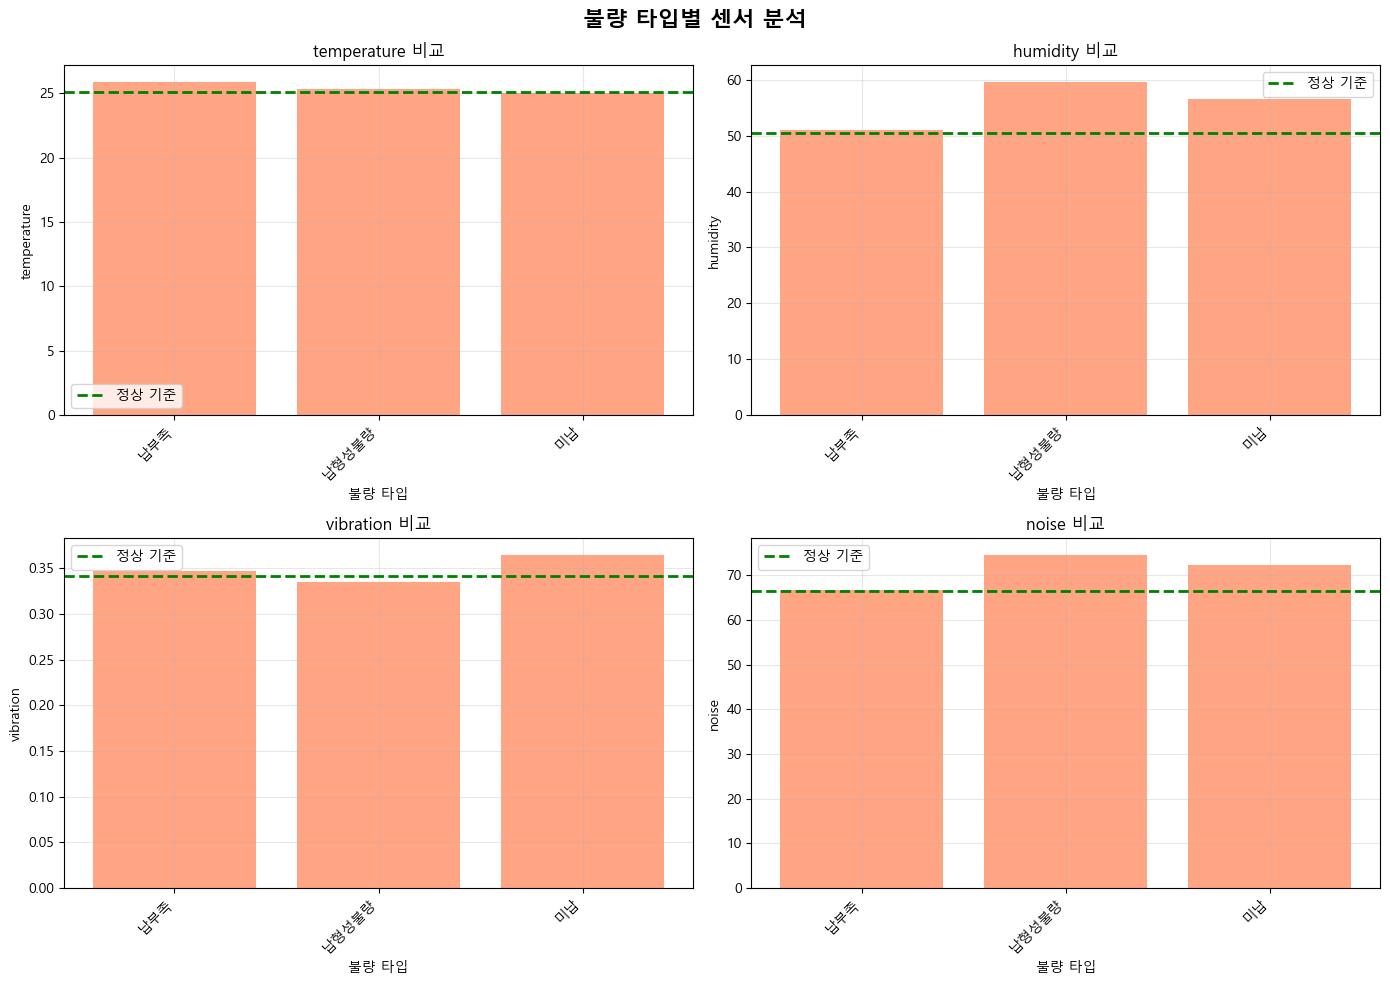

✓ 시각화 저장: ./outputs\defect_types_sensor_comparison.png

✅ 분석 완료!

📊 요약:
  • 총 불량 감지: 519개
  • 불량 타입: 3가지
  • 정상 기준값 설정 완료
  • 불량별 개선안 도출 완료

📁 결과:
  • ./outputs\defect_analysis_with_labels.json
  • ./outputs\defect_types_sensor_comparison.png


In [36]:
# ============================================================================
# Cell 1: 라이브러리 + 경로 설정
# ============================================================================

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT = "./smt_data"
LABEL_DIR = os.path.join(DATA_ROOT, "Sample/02.라벨링데이터/사전공정")
SENSOR_DIR = os.path.join(DATA_ROOT, "Sample/01.원천데이터/센서데이터/사전공정")
OUTPUT_DIR = "./outputs"

print("✓ 경로 설정 완료")


# ============================================================================
# Cell 2: 라벨링 JSON 파일 로드
# ============================================================================

# 라벨 파일들 찾기
label_files = []
for root, dirs, files in os.walk(LABEL_DIR):
    for file in files:
        if file.endswith('.json'):
            label_files.append(os.path.join(root, file))

print(f"✓ 라벨 파일 {len(label_files)}개 발견")

# 첫 번째 파일 확인
with open(label_files[0], 'r', encoding='utf-8') as f:
    sample_data = json.load(f)
    
print(f"\n첫 번째 파일 구조:")
print(f"  Categories: {len(sample_data['categories'])}개")
print(f"  Images: {len(sample_data['images'])}개")
print(f"  Annotations: {len(sample_data['annotations'])}개")
print(f"  Sensor Data: {len(sample_data['sensor_data'])}개")


# ============================================================================
# Cell 3: 모든 라벨링 데이터 통합
# ============================================================================

all_annotations = []
all_sensor_data = []

for label_file in label_files:
    with open(label_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
        # 카테고리 정보 (불량 타입)
        categories = {cat['id']: cat['name'] for cat in data['categories']}
        
        # 이미지별 센서 데이터
        for sensor_info in data['sensor_data']:
            image_id = sensor_info['image_id']
            
            # 해당 이미지의 annotations (bbox + 불량 타입)
            for annotation in data['annotations']:
                if annotation['image_id'] == image_id:
                    category_id = annotation['category_id']
                    category_name = categories[category_id]
                    
                    # 센서 데이터 시계열
                    sensor_sequence = sensor_info['sensor_sequence']
                    
                    # 불량 유형별로 정리
                    all_annotations.append({
                        'image_id': image_id,
                        'file': label_file,
                        'defect_type': category_name,
                        'category_id': category_id,
                        'bbox': annotation['bbox'],
                        'sensor_sequence': sensor_sequence
                    })

print(f"✓ 데이터 통합 완료: {len(all_annotations)}개 불량 감지")


# ============================================================================
# Cell 4: 불량 타입 분류
# ============================================================================

defect_types = list(set([a['defect_type'] for a in all_annotations]))
defect_types.sort()

print(f"✓ 불량 타입: {len(defect_types)}가지\n")

for i, dtype in enumerate(defect_types):
    count = len([a for a in all_annotations if a['defect_type'] == dtype])
    print(f"  {i+1}. {dtype}: {count}개")


# ============================================================================
# Cell 5: 센서 데이터 시계열 → 통계로 변환
# ============================================================================

def get_sensor_stats(sensor_sequence):
    """센서 시계열을 통계로 변환"""
    df = pd.DataFrame(sensor_sequence)
    
    stats = {}
    for col in ['temperature', 'humidity', 'vibration', 'acceleration', 'noise']:
        if col in df.columns:
            stats[f'{col}_mean'] = df[col].mean()
            stats[f'{col}_std'] = df[col].std()
            stats[f'{col}_max'] = df[col].max()
            stats[f'{col}_min'] = df[col].min()
    
    return stats

# 모든 불량에 센서 통계 추가
for annotation in all_annotations:
    sensor_stats = get_sensor_stats(annotation['sensor_sequence'])
    annotation.update(sensor_stats)

print("✓ 센서 통계 계산 완료")


# ============================================================================
# Cell 6: 불량 타입별 센서 분석
# ============================================================================

analysis_by_defect = {}

for dtype in defect_types:
    type_annotations = [a for a in all_annotations if a['defect_type'] == dtype]
    
    analysis = {
        'count': len(type_annotations),
        'sensor_stats': {}
    }
    
    # 센서별 평균값
    for col in ['temperature', 'humidity', 'vibration', 'acceleration', 'noise']:
        values = [a[f'{col}_mean'] for a in type_annotations if f'{col}_mean' in a]
        if values:
            analysis['sensor_stats'][col] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'min': np.min(values),
                'max': np.max(values)
            }
    
    analysis_by_defect[dtype] = analysis

print("✓ 불량 타입별 분석 완료")


# ============================================================================
# Cell 7: 정상 vs 불량 비교
# ============================================================================

normal_types = [dtype for dtype in defect_types if '정상' in dtype]
defect_only_types = [dtype for dtype in defect_types if '불량' in dtype]

print(f"✓ 분류:")
print(f"  정상: {len(normal_types)}가지")
print(f"  불량: {len(defect_only_types)}가지")

# 정상의 평균값 (기준)
normal_baseline = {}
for sensor_col in ['temperature', 'humidity', 'vibration', 'acceleration', 'noise']:
    values = []
    for dtype in normal_types:
        if sensor_col in analysis_by_defect[dtype]['sensor_stats']:
            values.append(analysis_by_defect[dtype]['sensor_stats'][sensor_col]['mean'])
    if values:
        normal_baseline[sensor_col] = np.mean(values)

print(f"\n정상 기준값:")
for sensor, value in normal_baseline.items():
    print(f"  {sensor}: {value:.2f}")


# ============================================================================
# Cell 8: 불량 타입별 원인 규명
# ============================================================================

print("\n" + "="*70)
print("불량 타입별 센서 분석 결과")
print("="*70 + "\n")

improvement_by_defect = {}

for dtype in defect_only_types:
    print(f"🔴 {dtype} ({analysis_by_defect[dtype]['count']}개)")
    
    improvements = []
    
    for sensor, stats in analysis_by_defect[dtype]['sensor_stats'].items():
        baseline = normal_baseline[sensor]
        diff = stats['mean'] - baseline
        diff_pct = (diff / baseline * 100) if baseline != 0 else 0
        status = "↑ 높음" if diff > 0 else "↓ 낮음"
        
        print(f"  {sensor}: {stats['mean']:.2f} vs 정상 {baseline:.2f} ({diff_pct:+.1f}%) {status}")
        
        if abs(diff_pct) > 5:  # 5% 이상 차이
            improvement = f"{sensor}: {baseline:.2f}로 조정 필요"
            improvements.append(improvement)
    
    if improvements:
        print("  → 개선안:")
        for imp in improvements:
            print(f"     • {imp}")
    else:
        print("  → 특별한 조정 불필요")
    
    improvement_by_defect[dtype] = improvements
    print()


# ============================================================================
# Cell 9: 불량 타입별 공정 개선 설정값
# ============================================================================

print("="*70)
print("공정 설정값 조정 제안")
print("="*70 + "\n")

recommended_settings = {}

for dtype in defect_only_types:
    print(f"📋 {dtype}")
    
    settings = {}
    for sensor, stats in analysis_by_defect[dtype]['sensor_stats'].items():
        baseline = normal_baseline[sensor]
        
        if sensor == 'temperature':
            settings['temperature'] = round(baseline, 1)
            print(f"  • 온도: {stats['mean']:.2f} → {baseline:.1f}°C")
        elif sensor == 'humidity':
            settings['humidity'] = round(baseline, 1)
            print(f"  • 습도: {stats['mean']:.2f} → {baseline:.1f}%")
        elif sensor == 'vibration':
            settings['vibration_max'] = round(baseline, 3)
            print(f"  • 진동: {stats['mean']:.4f} → {baseline:.3f}m/s²")
        elif sensor == 'acceleration':
            settings['acceleration_max'] = round(baseline, 4)
            print(f"  • 가속도: {stats['mean']:.4f} → {baseline:.4f}g")
        elif sensor == 'noise':
            settings['noise_max'] = round(baseline, 1)
            print(f"  • 소음: {stats['mean']:.2f} → {baseline:.1f}dB")
    
    recommended_settings[dtype] = settings
    print()


# ============================================================================
# Cell 10: 결과 저장
# ============================================================================

output_data = {
    'total_annotations': len(all_annotations),
    'defect_types': len(defect_only_types),
    'normal_baseline': {k: round(v, 3) for k, v in normal_baseline.items()},
    'defect_analysis': {
        dtype: {
            'count': analysis_by_defect[dtype]['count'],
            'sensors': {
                sensor: {
                    'mean': round(stats['mean'], 3),
                    'std': round(stats['std'], 3),
                    'min': round(stats['min'], 3),
                    'max': round(stats['max'], 3)
                }
                for sensor, stats in analysis_by_defect[dtype]['sensor_stats'].items()
            }
        }
        for dtype in defect_only_types
    },
    'recommended_settings': recommended_settings,
    'improvements': improvement_by_defect
}

import json
os.makedirs(OUTPUT_DIR, exist_ok=True)
output_file = os.path.join(OUTPUT_DIR, "defect_analysis_with_labels.json")
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)

print(f"✓ 결과 저장: {output_file}")


# ============================================================================
# Cell 11: 시각화 - 불량 타입별 센서 비교
# ============================================================================

# 불량 타입만 선택
sensors_to_plot = ['temperature', 'humidity', 'vibration', 'noise']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('불량 타입별 센서 분석', fontsize=16, fontweight='bold')

for idx, sensor in enumerate(sensors_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    defect_means = []
    defect_labels = []
    
    for dtype in defect_only_types:
        if sensor in analysis_by_defect[dtype]['sensor_stats']:
            defect_means.append(analysis_by_defect[dtype]['sensor_stats'][sensor]['mean'])
            defect_labels.append(dtype.replace('불량_', ''))
    
    baseline = normal_baseline.get(sensor, 0)
    
    # 막대 그래프
    bars = ax.bar(range(len(defect_means)), defect_means, color='coral', alpha=0.7)
    ax.axhline(y=baseline, color='green', linestyle='--', linewidth=2, label='정상 기준')
    
    ax.set_ylabel(sensor)
    ax.set_xlabel('불량 타입')
    ax.set_title(f'{sensor} 비교')
    ax.set_xticks(range(len(defect_labels)))
    ax.set_xticklabels(defect_labels, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
output_fig = os.path.join(OUTPUT_DIR, "defect_types_sensor_comparison.png")
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ 시각화 저장: {output_fig}")


# ============================================================================
# Cell 12: 최종 요약
# ============================================================================

print("\n" + "="*70)
print("✅ 분석 완료!")
print("="*70)
print(f"\n📊 요약:")
print(f"  • 총 불량 감지: {len(all_annotations)}개")
print(f"  • 불량 타입: {len(defect_only_types)}가지")
print(f"  • 정상 기준값 설정 완료")
print(f"  • 불량별 개선안 도출 완료")
print(f"\n📁 결과:")
print(f"  • {output_file}")
print(f"  • {output_fig}")